In [1]:
import pandas as pd
import numpy as np
df = pd.read_excel('BASE_2_Clientes_Manga.xlsx')

In [2]:
from catboost import CatBoostClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    f1_score,
    recall_score,
    precision_score,
    balanced_accuracy_score,
    confusion_matrix,
    classification_report
)

target = "importancia_preco"

features = [
    "volume_tipico_compra_ton_mes",
    "importancia_certificacoes",
    "aceita_refugo_como_mp",
    "tipo_cliente",
    "frequencia_compra_mensal",
    "importancia_manga_produto_final_1a10"
]

cat_features = [
    "importancia_certificacoes",
    "aceita_refugo_como_mp",
    "tipo_cliente"
]

df_train = df[df[target].notna()].copy()
df_missing = df[df[target].isna()].copy()

X = df_train[features]
y = df_train[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

model = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    loss_function="MultiClass",
    random_seed=42,
    verbose=False
)

model.fit(X_train, y_train, cat_features=cat_features)

y_pred = model.predict(X_test)

# CatBoost às vezes retorna shape (n, 1)
if isinstance(y_pred, (np.ndarray,)) and y_pred.ndim > 1:
    y_pred = y_pred.ravel()

# se vier como lista de listas, também resolve
y_pred = np.array(y_pred).ravel()

# =========================
# MÉTRICAS (ordem prática)
# =========================
f1_macro = f1_score(y_test, y_pred, average="macro")
recall_macro = recall_score(y_test, y_pred, average="macro")
precision_macro = precision_score(y_test, y_pred, average="macro", zero_division=0)
bal_acc = balanced_accuracy_score(y_test, y_pred)

print("✅ Métricas (macro):")
print(f"1) F1 macro           : {f1_macro:.4f}")
print(f"2) Recall macro       : {recall_macro:.4f}")
print(f"3) Precision macro    : {precision_macro:.4f}")
print(f"4) Balanced accuracy  : {bal_acc:.4f}")

# =========================
# MATRIZ DE CONFUSÃO
# =========================
labels = sorted(pd.Series(y_test).dropna().unique().tolist())
cm = confusion_matrix(y_test, y_pred, labels=labels)
cm_df = pd.DataFrame(cm, index=[f"real_{l}" for l in labels], columns=[f"pred_{l}" for l in labels])

print("\n✅ Matriz de confusão:")
display(cm_df)

# =========================
# (extra útil) relatório por classe
# =========================
print("\n✅ Relatório por classe:")
print(classification_report(y_test, y_pred, zero_division=0))

from sklearn.metrics import f1_score

pred_train = model.predict(X_train).ravel()
pred_test  = model.predict(X_test).ravel()

print("F1 macro treino:", f1_score(y_train, pred_train, average="macro"))
print("F1 macro teste :", f1_score(y_test,  pred_test,  average="macro"))

target = "importancia_preco"

df_missing = df[df[target].isna()].copy()
df_observed = df[df[target].notna()].copy()
pred_missing = model.predict(df_missing[features])

# garante formato correto
import numpy as np
pred_missing = np.array(pred_missing).ravel()

df.loc[df[target].isna(), target] = pred_missing

✅ Métricas (macro):
1) F1 macro           : 0.6562
2) Recall macro       : 0.6586
3) Precision macro    : 0.6555
4) Balanced accuracy  : 0.6586

✅ Matriz de confusão:


,pred_Alta,pred_Baixa,pred_Média
real_Alta,517,0,111
real_Baixa,4,168,67
real_Média,147,77,183



✅ Relatório por classe:
              precision    recall  f1-score   support

        Alta       0.77      0.82      0.80       628
       Baixa       0.69      0.70      0.69       239
       Média       0.51      0.45      0.48       407

    accuracy                           0.68      1274
   macro avg       0.66      0.66      0.66      1274
weighted avg       0.67      0.68      0.68      1274

F1 macro treino: 0.6751106413147324
F1 macro teste : 0.6562056274019658


In [3]:
map_importancia = {
    'Baixa': 1,
    'Média': 2,
    'Alta': 3
}

map_sim_nao = {
    'Não': 0,
    'Sim': 1
}

df_cluster = df.copy()

df_cluster['importancia_preco'] = df_cluster['importancia_preco'].map(map_importancia)
df_cluster['importancia_certificacoes'] = df_cluster['importancia_certificacoes'].map(map_importancia)
df_cluster['aceita_refugo_como_mp'] = df_cluster['aceita_refugo_como_mp'].map(map_sim_nao)

In [4]:
features = [
    'importancia_manga_produto_final_1a10',
    'importancia_preco',
    'importancia_certificacoes',
    'aceita_refugo_como_mp',
    'volume_tipico_compra_ton_mes',
    'frequencia_compra_mensal'
]

X = df_cluster[features]

In [5]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

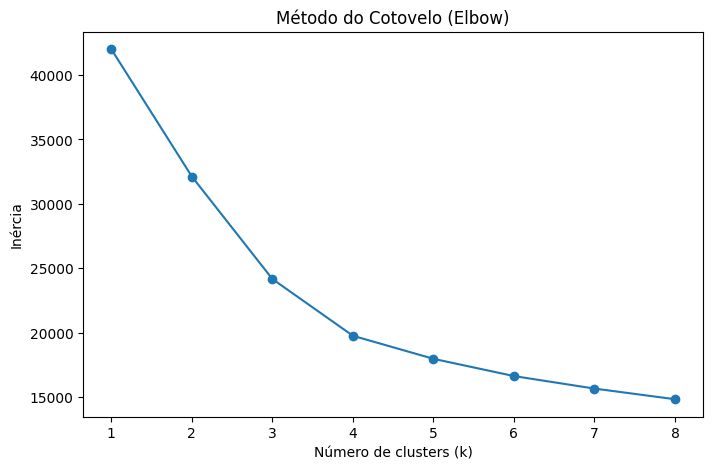

In [6]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []

K = range(1, 9)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8,5))
plt.plot(K, inertias, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inércia')
plt.title('Método do Cotovelo (Elbow)')
plt.show()

In [7]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)

In [8]:
cluster_profile = (
    df_cluster
    .groupby('cluster')[features]
    .mean()
    .round(2)
)

cluster_profile

,importancia_manga_produto_final_1a10,importancia_preco,importancia_certificacoes,aceita_refugo_como_mp,volume_tipico_compra_ton_mes,frequencia_compra_mensal
cluster,,,,,,
0,7.98,1.36,2.72,0.13,284.94,3.03
1,8.54,2.82,1.71,0.88,1271.46,3.45
2,5.96,2.83,2.72,0.51,1817.97,2.50
3,6.81,2.11,1.32,0.80,458.43,4.16


In [9]:
pd.crosstab(
    df_cluster['cluster'],
    df_cluster['tipo_cliente'],
    normalize='index'
).round(2)

tipo_cliente,B2B,B2C
cluster,,
0,0.98,0.02
1,0.89,0.11
2,1.00,0.00
3,0.72,0.28


In [11]:
df_cluster['cluster'].value_counts().sort_index()

cluster
0    1517
1    2581
2    1279
3    1623
Name: count, dtype: int64

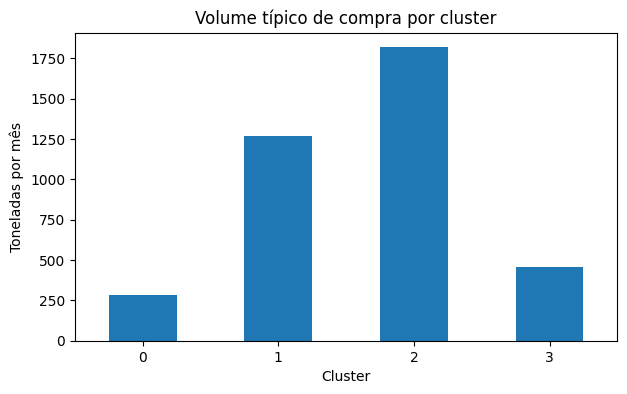

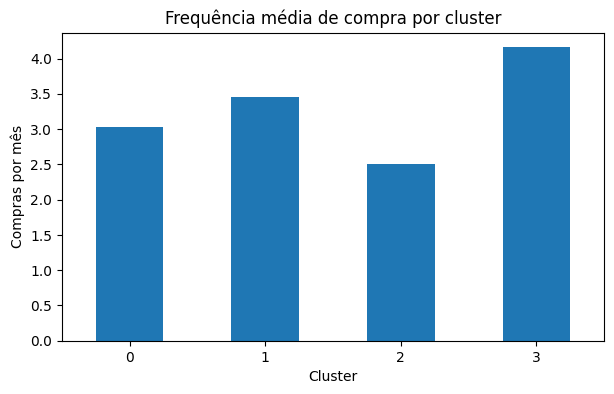

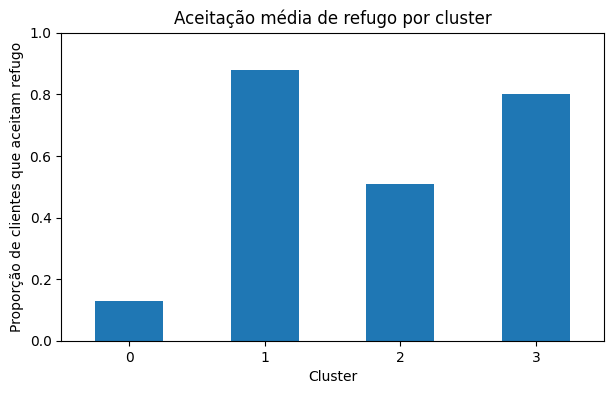

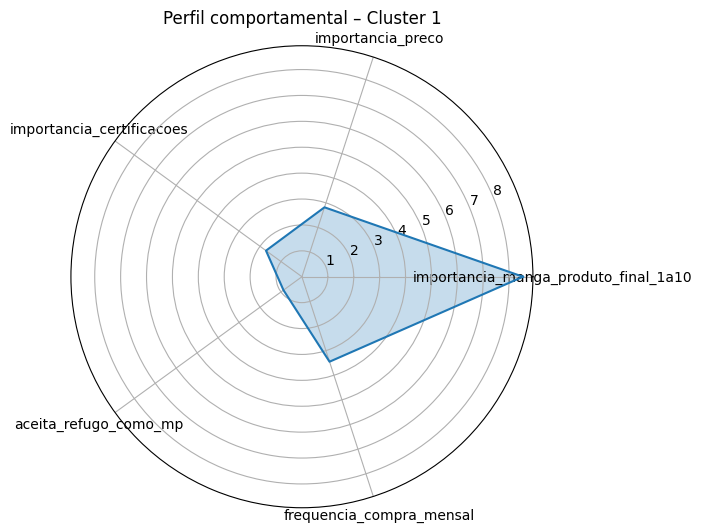

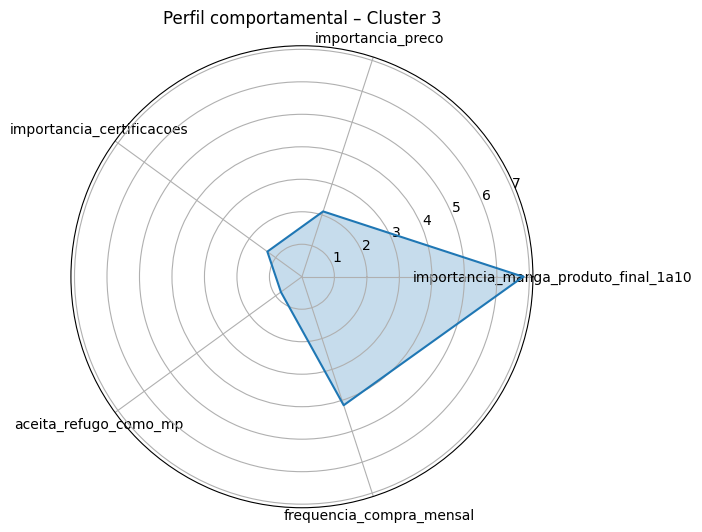

<Figure size 700x400 with 0 Axes>

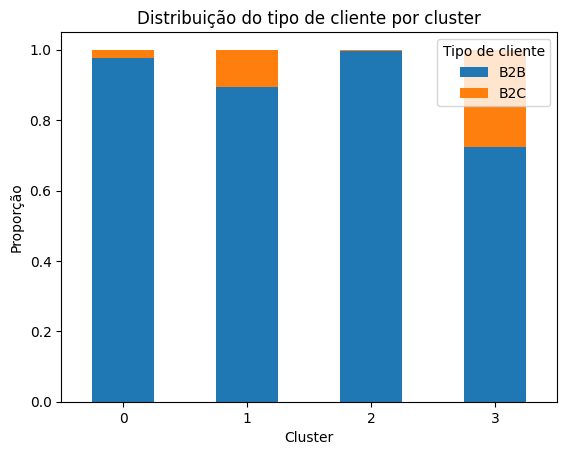

In [10]:
# ============================================================
# VISUALIZAÇÃO COMPLETA DOS CLUSTERS (UMA ÚNICA CÉLULA)
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# ----------------------------
# 1) VOLUME MÉDIO POR CLUSTER
# ----------------------------
plt.figure(figsize=(7,4))
cluster_profile['volume_tipico_compra_ton_mes'].plot(kind='bar')
plt.title('Volume típico de compra por cluster')
plt.ylabel('Toneladas por mês')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.show()

# ----------------------------
# 2) FREQUÊNCIA MÉDIA DE COMPRA
# ----------------------------
plt.figure(figsize=(7,4))
(
    df_cluster
    .groupby('cluster')['frequencia_compra_mensal']
    .mean()
    .plot(kind='bar')
)
plt.title('Frequência média de compra por cluster')
plt.ylabel('Compras por mês')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.show()

# ----------------------------
# 3) ACEITAÇÃO DE REFUGO
# ----------------------------
plt.figure(figsize=(7,4))
cluster_profile['aceita_refugo_como_mp'].plot(kind='bar')
plt.title('Aceitação média de refugo por cluster')
plt.ylabel('Proporção de clientes que aceitam refugo')
plt.xlabel('Cluster')
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.show()

# ----------------------------
# 4) RADAR – PERFIL COMPORTAMENTAL (CLUSTERS 1 E 3)
# ----------------------------
radar_vars = [
    'importancia_manga_produto_final_1a10',
    'importancia_preco',
    'importancia_certificacoes',
    'aceita_refugo_como_mp',
    'frequencia_compra_mensal'
]

angles = np.linspace(0, 2*np.pi, len(radar_vars), endpoint=False).tolist()
angles += angles[:1]

for cluster_id in [1, 3]:
    values = (
        df_cluster
        .groupby('cluster')[radar_vars]
        .mean()
        .loc[cluster_id]
        .tolist()
    )
    values += values[:1]

    plt.figure(figsize=(6,6))
    ax = plt.subplot(111, polar=True)
    ax.plot(angles, values)
    ax.fill(angles, values, alpha=0.25)
    ax.set_thetagrids(np.degrees(angles[:-1]), radar_vars)
    ax.set_title(f'Perfil comportamental – Cluster {cluster_id}')
    plt.show()

# ----------------------------
# 5) TIPO DE CLIENTE (B2B x B2C)
# ----------------------------
plt.figure(figsize=(7,4))
(
    pd.crosstab(df_cluster['cluster'], df_cluster['tipo_cliente'], normalize='index')
    .plot(kind='bar', stacked=True)
)
plt.title('Distribuição do tipo de cliente por cluster')
plt.ylabel('Proporção')
plt.xlabel('Cluster')
plt.xticks(rotation=0)
plt.legend(title='Tipo de cliente')
plt.show()
